In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import shap

import warnings
warnings.filterwarnings('ignore')

In [12]:
print("Loading model and data...")
model = joblib.load('../../models/lightgbm_churn_model.pkl')
X_train = pd.read_csv('../../data/04_features/X_train.csv')
y_train = pd.read_csv('../../data/04_features/y_train.csv').squeeze()
X_test = pd.read_csv('../../data/04_features/X_test.csv')
y_test = pd.read_csv('../../data/04_features/y_test.csv').squeeze()

print("Generating predictions...")
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

Loading model and data...
Generating predictions...


In [13]:
print("--- Model Evaluation Metrics ---")
def print_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Metrics for {dataset_name}:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision (Macro): {prec:.4f}")
    print(f"  Recall (Macro)   : {rec:.4f}")
    print(f"  F1 Score (Macro) : {f1:.4f}")
    print("-" * 30)

print_metrics(y_train, y_train_pred, "Training Set")
print_metrics(y_test, y_test_pred, "Testing Set")

print("Classification Report (Testing Set):\n")
print(classification_report(y_test, y_test_pred))

--- Model Evaluation Metrics ---
Metrics for Training Set:
  Accuracy : 0.8949
  Precision (Macro): 0.8501
  Recall (Macro)   : 0.8727
  F1 Score (Macro) : 0.8566
------------------------------
Metrics for Testing Set:
  Accuracy : 0.8158
  Precision (Macro): 0.7554
  Recall (Macro)   : 0.7692
  F1 Score (Macro) : 0.7525
------------------------------
Classification Report (Testing Set):

              precision    recall  f1-score   support

           0       0.79      0.63      0.70       427
           1       0.48      0.70      0.57       214
           2       1.00      0.98      0.99       640

    accuracy                           0.82      1281
   macro avg       0.76      0.77      0.75      1281
weighted avg       0.84      0.82      0.82      1281



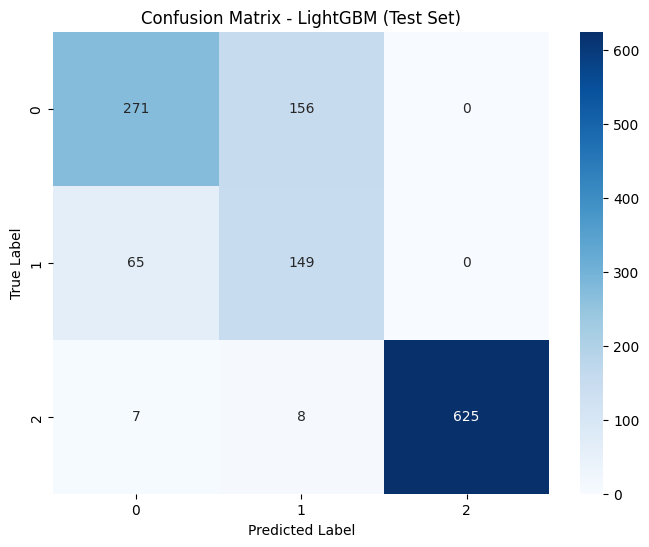

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - LightGBM (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Initializing SHAP TreeExplainer...
Detected multiclass SHAP values with shape: (1281, 20, 3)
SHAP Summary Plot (Global Explainability for Class 1):


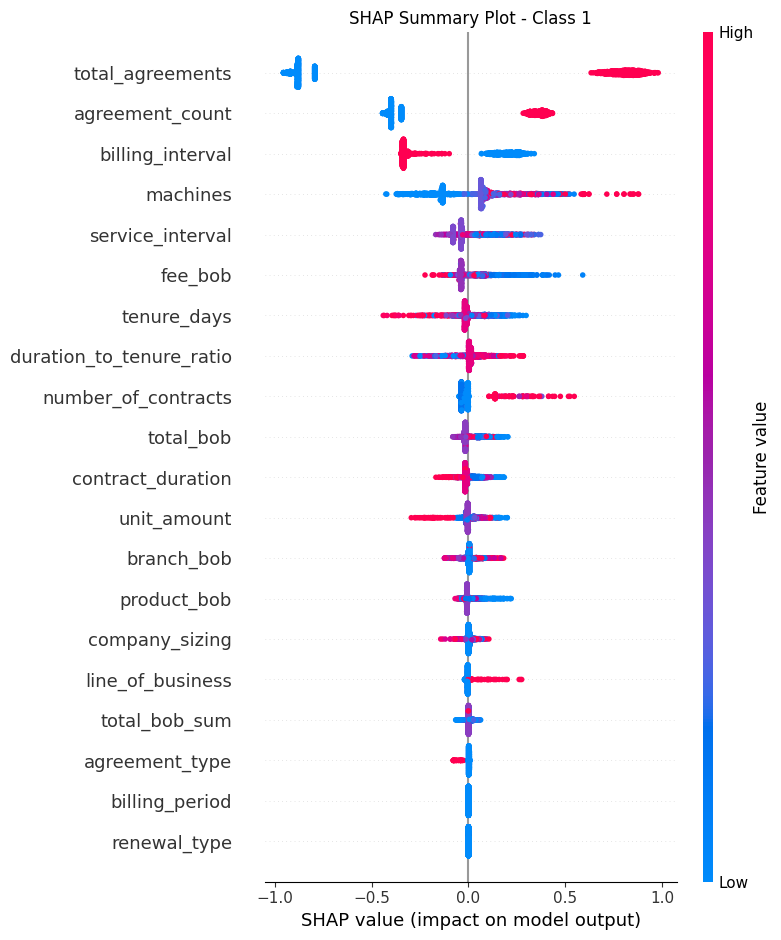

SHAP Feature Importance (Bar Plot for Class 1):


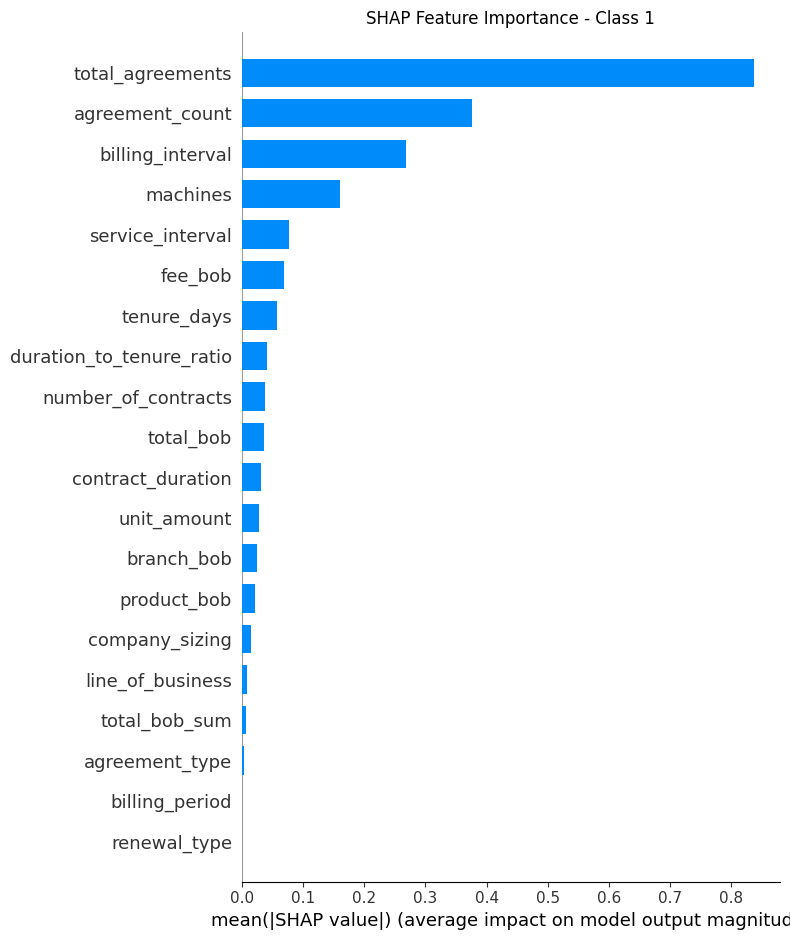

SHAP Dependence Plot for Top Feature: total_agreements


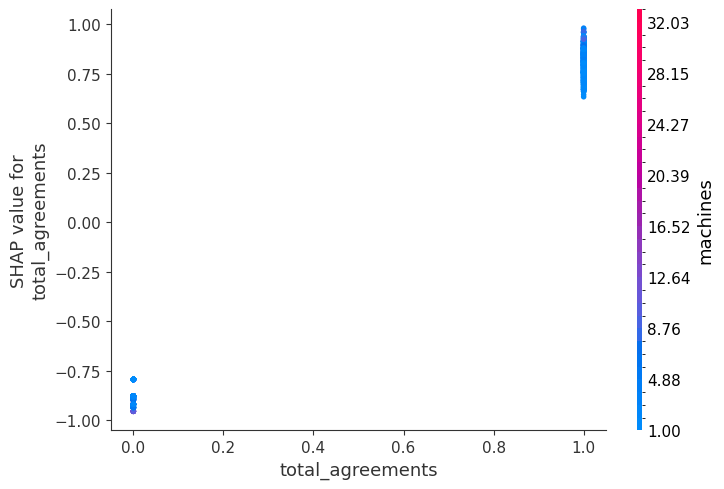

In [15]:
# SHAP Explainability
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle multiclass shape (samples, features, classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    print(f"Detected multiclass SHAP values with shape: {shap_values.shape}")
    # Using index 1 (usually the first churn class) for specific plots
    shap_values_to_plot = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

print("SHAP Summary Plot (Global Explainability for Class 1):")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test, show=False)
plt.title('SHAP Summary Plot - Class 1')
plt.tight_layout()
plt.show()

print("SHAP Feature Importance (Bar Plot for Class 1):")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Class 1')
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X_test.columns[top_feature_idx]

print(f"SHAP Dependence Plot for Top Feature: {top_feature_name}")
shap.dependence_plot(top_feature_name, shap_values_to_plot, X_test, show=False)
plt.tight_layout()
plt.show()